# t-SNE


In [8]:
# Import necessary libraries
import numpy as np
from sklearn.manifold import TSNE
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import pairwise_distances
from sklearn.neighbors import NearestNeighbors
from scipy.spatial.distance import pdist, squareform
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.datasets import load_digits


import time


np.random.seed(42)

# Design your algorithm
Make sure to describe the algorithm, its limitations, and describe use-cases.

Theoretical Overview
t-SNE (t-Distributed Stochastic Neighbor Embedding) is a method for reducing high-dimensional data to low dimensions (2D or 3D) for visualization. It tries to preserve the local structure of the data by modeling the similarities between points as probabilities. In high dimensions, these probabilities are calculated using Gaussian kernels, and in low dimensions, a Student-t distribution is used to avoid crowding.

The algorithm minimizes the KL divergence between the probability distributions in the high-dimensional and low-dimensional spaces using gradient descent.

Practical Considerations
Perplexity: Controls the size of the local neighborhood and balances local and global patterns.
Learning Rate: Affects the optimization speed; too high or too low can harm convergence.
Iterations: More iterations improve optimization but increase runtime.
Use Cases: t-SNE is used for data visualization in clustering and finding patterns in complex datasets. (DNA, MNIST...)

Limitations include high computational cost, especially for large datasets, and a focus on local structures, which may lose global relationships.



# Your implementations
You may add new cells, write helper functions or test code as you see fit.
Please use the cell below and include a description of your implementation.
Explain code design consideration, algorithmic choices and any other details you think is relevant to understanding your implementation.
Failing to explain your code will lead to point deductions.

In [22]:
class CustomTSNE:
    def __init__(self, perplexity=30.0, n_components=2, n_iter=1000, learning_rate=200.0, momentum=0.5, n_jobs=-1, tol=1e-5, max_iter=50):
        """t-SNE implementation with integrated binary search for sigma optimization."""
        self.perplexity = perplexity
        self.n_components = n_components
        self.n_iter = n_iter
        self.learning_rate = learning_rate
        self.momentum = momentum
        self.n_jobs = n_jobs
        self.tol = tol
        self.max_iter = max_iter
        self.rng = np.random.default_rng(seed=42)
        self.prev_deltas = None  # For applying momentum to gradient updates

    def _compute_dist_matrix(self, data):
        """Calculate squared pairwise distances for the dataset."""
        return pairwise_distances(data, metric='euclidean', squared=True)

    def _calculate_perplexity_probs(self, distances, sigma):
        """Compute conditional probabilities and entropy for a given sigma."""
        exp_scaled = np.exp(-distances / (2 * sigma * sigma))
        total = np.sum(exp_scaled)

        if total == 0:
            return float('inf'), np.zeros_like(exp_scaled)  # Handle numerical instability

        prob_matrix = exp_scaled / total
        entropy = -np.sum(prob_matrix * np.log2(prob_matrix + 1e-12))
        perplexity = 2 ** entropy
        return perplexity, prob_matrix

    def _find_optimal_sigma(self, distances):
        """Use binary search to determine the best sigma for the desired perplexity."""
        low, high = 1e-20, 1e20
        sigma = 1.0

        for _ in range(self.max_iter):
            current_perplexity, prob_row = self._calculate_perplexity_probs(distances, sigma)

            if abs(current_perplexity - self.perplexity) < self.tol:
                break

            if current_perplexity > self.perplexity:
                high = sigma
            else:
                low = sigma

            sigma = (low + high) / 2

        return prob_row

    def _compute_prob_matrix(self, distances):
        """Convert high-dimensional pairwise distances to probabilities."""
        n_samples = distances.shape[0]
        prob_matrix = np.zeros((n_samples, n_samples))

        for idx in range(n_samples):
            row_dists = distances[idx, np.concatenate((np.r_[0:idx], np.r_[idx+1:n_samples]))]
            prob_matrix[idx, np.concatenate((np.r_[0:idx], np.r_[idx+1:n_samples]))] = self._find_optimal_sigma(row_dists)

        prob_matrix = (prob_matrix + prob_matrix.T) / (2 * n_samples)
        prob_matrix = np.maximum(prob_matrix, 1e-12)  # For numerical stability
        return prob_matrix

    def _low_dim_probs(self, embedding):
        """Calculate pairwise probabilities in the low-dimensional space."""
        low_dim_dists = self._compute_dist_matrix(embedding)
        inv_dists = 1 / (1 + low_dim_dists)
        np.fill_diagonal(inv_dists, 0)

        normalized_probs = inv_dists / np.sum(inv_dists)
        normalized_probs = np.maximum(normalized_probs, 1e-12)  # Numerical stability
        return normalized_probs, inv_dists

    def _gradient_update(self, high_dim_probs, low_dim_probs, embedding, inv_dists):
        """Compute gradient updates for optimizing the KL divergence."""
        n_samples = embedding.shape[0]
        grad_updates = np.zeros((n_samples, self.n_components))

        for i in range(n_samples):
            differences = embedding[i] - embedding
            weighted_diffs = (high_dim_probs[i] - low_dim_probs[i]) * inv_dists[i]
            grad_updates[i] = 4 * np.sum(differences * weighted_diffs[:, None], axis=0)

        return grad_updates

    def fit_transform(self, X):
        """Main method to fit t-SNE and transform the data."""
        n_samples = X.shape[0]

        # Initialize embedding with small random values
        embedding = self.rng.normal(0, 1e-4, size=(n_samples, self.n_components))

        # Compute high-dimensional probabilities
        dist_matrix = self._compute_dist_matrix(X)
        high_dim_probs = self._compute_prob_matrix(dist_matrix)

        kl_history = []  # To track KL divergence over iterations

        # Gradient descent iterations
        for iteration in range(self.n_iter):
            low_dim_probs, inv_dists = self._low_dim_probs(embedding)
            gradients = self._gradient_update(high_dim_probs, low_dim_probs, embedding, inv_dists)

            # Apply momentum to gradients
            if self.prev_deltas is not None:
                gradients += self.momentum * self.prev_deltas
            self.prev_deltas = gradients

            # Update the embedding
            embedding -= self.learning_rate * gradients

            # Zero-center the embedding
            embedding -= np.mean(embedding, axis=0)

            # Calculate KL divergence
            kl_div = np.sum(high_dim_probs * np.log(high_dim_probs / low_dim_probs))
            kl_history.append(kl_div)

            if (iteration + 1) % 100 == 0:
                print(f"Iteration {iteration + 1}: KL divergence = {kl_div}")

        # Plot KL divergence
        self.plot_kl_divergence(kl_history)
        return embedding

    def plot_kl_divergence(self, kl_history):
        """Plot the KL divergence over iterations."""
        plt.figure(figsize=(8, 5))
        plt.plot(kl_history)
        plt.xlabel("Iteration")
        plt.ylabel("KL Divergence")
        plt.title("KL Divergence Over Iterations")
        plt.grid()
        plt.show()


    def transform(self, X_train, custom_Y, X_test):
      """Transform new points into the existing t-SNE embedding with consistent scale."""
      # Compute pairwise distances between test points and training points
      distances = pairwise_distances(X_test, X_train, metric='euclidean', squared=True)

      # Initialize the transformed embeddings
      n_test = X_test.shape[0]
      transformed_Y = np.zeros((n_test, self.n_components))

      for i in range(n_test):
          test_point_dists = distances[i]

          # Use the training data's sigma to calculate affinities (weights)
          prob_row = self._find_optimal_sigma(test_point_dists)  # Ensure this returns probabilities

          # Map the test point into the low-dimensional space
          transformed_Y[i] = np.sum(prob_row[:, None] * custom_Y, axis=0)

      return transformed_Y




**High-Dimensional Probabilities**

The _compute_prob_matrix method calculates high-dimensional probabilities
𝑃𝑖𝑗
  using a Gaussian kernel on pairwise distances. The _find_optimal_sigma method adjusts the Gaussian bandwidth (
𝜎
) for each point using binary search to match the specified perplexity. This ensures consistent neighborhood sizes across points.

*Design Consideration:*
Binary search balances accuracy and efficiency, while symmetric normalization ensures proper scaling of probabilities.

**Low-Dimensional Probabilities**
The _low_dim_probs method computes low-dimensional probabilities
𝑄𝑖𝑗
  using a Student-t distribution, which addresses the crowding problem by better spreading distant points in the low-dimensional space. Probabilities are normalized and diagonal values are set to zero.

*Algorithmic Choice:*
The Student-t distribution is more effective for low-dimensional embeddings by reducing the influence of distant outliers.

**Optimization Strategy**
The fit_transform method minimizes KL divergence between
𝑃𝑖𝑗
  and
𝑄𝑖𝑗
  using gradient descent, with gradients computed in _gradient_update. Momentum is applied to smooth updates, and the embedding is initialized with small random values close to zero to avoid bias.

*Code Design Considerations:*

Modular gradient computation ensures readability and reusability.
KL divergence is monitored during iterations, allowing users to track convergence progress.

**Transforming New Data**
The transform method maps new high-dimensional data points into an existing low-dimensional t-SNE embedding while maintaining consistent scaling. It first calculates the pairwise Euclidean distances between the test data (X_test) and the training data (X_train). Then, for each test point, it computes the optimal sigma (using _find_optimal_sigma) to derive affinity probabilities between the test point and the training points. Finally, the function uses these probabilities to create a weighted sum of the training data's low-dimensional embeddings (custom_Y), yielding a low-dimensional representation for the test data.




Handle hyperparameters correctly: In the next parts

# Load data
Please use the cell below to discuss your dataset choice and why it is appropriate (or not) for this algorithm.

We chose digits dataset for this notebook.
The digits dataset is a good choice for demonstrating t-SNE because it consists of high-dimensional data (images of handwritten digits) that can be effectively reduced to reveal clear clusters. Its simplicity and popularity make it a good example for showing how t-SNE works to visualize patterns in data.

In [4]:
data = load_digits()
X = data.data
y = data.target
scaler = MinMaxScaler()
X_normalized = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_normalized, y, test_size=0.2, random_state=42)


In [5]:
X_test.shape[0]+X_train.shape[0]

1797


**Preprocessing the Data for t-SNE**

The dataset is used to represent handwritten digits as a high dimensional feature vectors (X) with corresponding labels (y). To prepare the data for t-SNE, the features are normalized to the range [0, 1] using MinMaxScaler. This step ensures that all features contribute equally to the distance computations, which are critical for t-SNE. The dataset is then split into training and testing sets using train_test_split, with 60% for training and 40% for testing, enabling separate embeddings for testing the model.

# t-SNE demonstration
Demonstrate your t-SNE implementation.

Add plots and figures. The code below is just to help you get started, and should not be your final submission.

Please use the cell below to describe your results and tests.

Describe the difference between your implementation and the sklearn implementation. Hint: you can look at the documentation.

## Hyper param selection

Iteration 100: KL divergence = 2.6180052434927714
Iteration 200: KL divergence = 2.1618571816382923
Iteration 300: KL divergence = 1.9418130430976286
Iteration 400: KL divergence = 1.8048412442025636
Iteration 500: KL divergence = 1.7084658886254422
Iteration 600: KL divergence = 1.6353496471975242
Iteration 700: KL divergence = 1.5770782147773585
Iteration 800: KL divergence = 1.5291751011282648
Iteration 900: KL divergence = 1.488656433294033
Iteration 1000: KL divergence = 1.4535098500993824


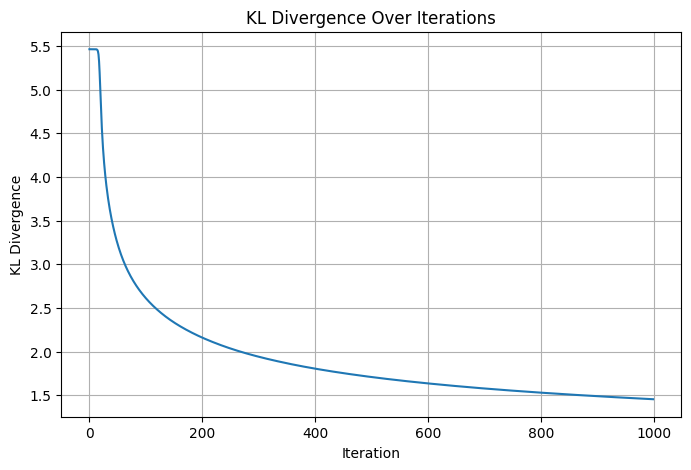

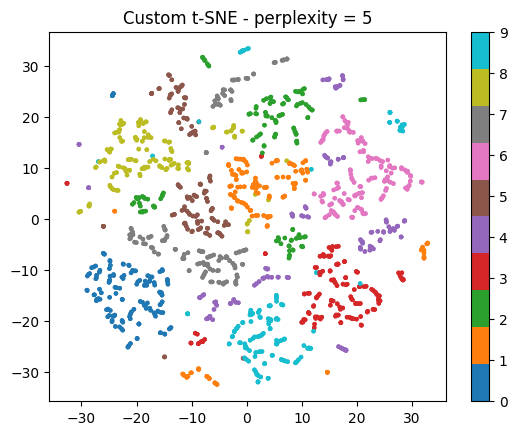

Iteration 100: KL divergence = 1.4427954917254744
Iteration 200: KL divergence = 1.1988550164949956
Iteration 300: KL divergence = 1.0946798815727945
Iteration 400: KL divergence = 1.032743452964077
Iteration 500: KL divergence = 0.9902626161658089
Iteration 600: KL divergence = 0.9587505942106908
Iteration 700: KL divergence = 0.9342190016034557
Iteration 800: KL divergence = 0.9143678747934103
Iteration 900: KL divergence = 0.8979170575757587
Iteration 1000: KL divergence = 0.8839446597557908


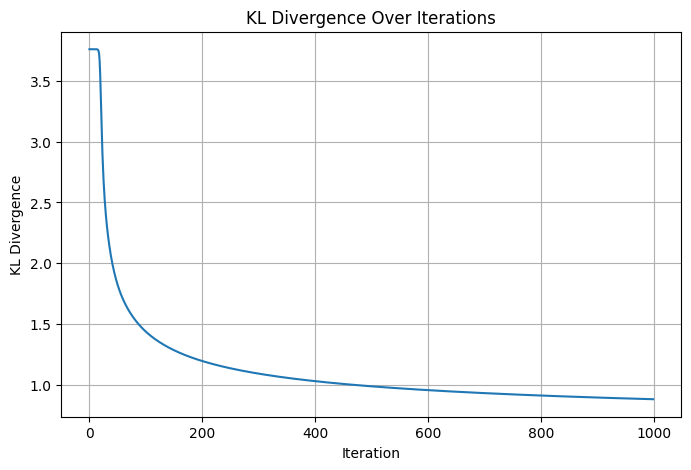

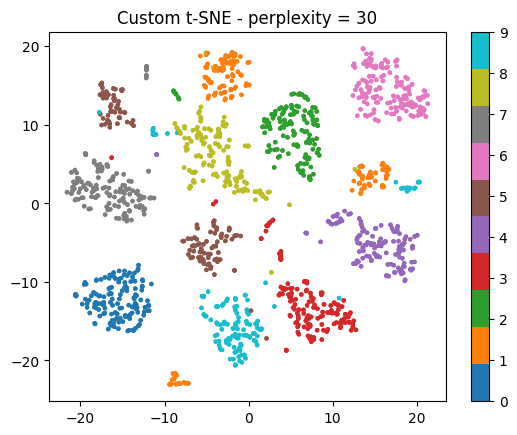

Iteration 100: KL divergence = 1.16475903695301
Iteration 200: KL divergence = 0.9699267872596408
Iteration 300: KL divergence = 0.8894180290202659
Iteration 400: KL divergence = 0.8425583912176735
Iteration 500: KL divergence = 0.8109939495239155
Iteration 600: KL divergence = 0.78790051212008
Iteration 700: KL divergence = 0.7699951080964117
Iteration 800: KL divergence = 0.755557303590279
Iteration 900: KL divergence = 0.7438206796815415
Iteration 1000: KL divergence = 0.7340244464240296


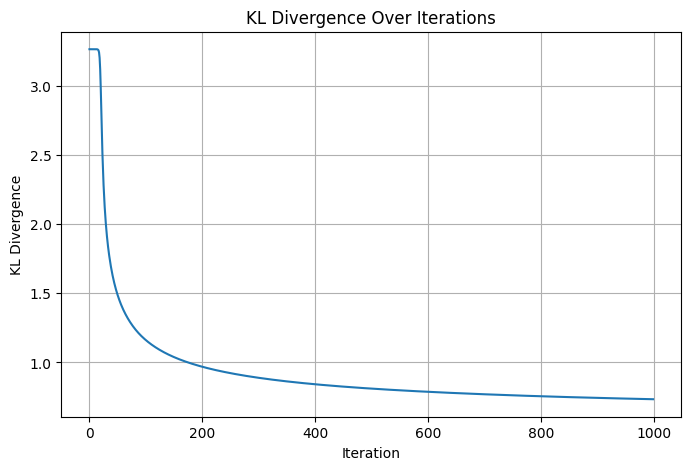

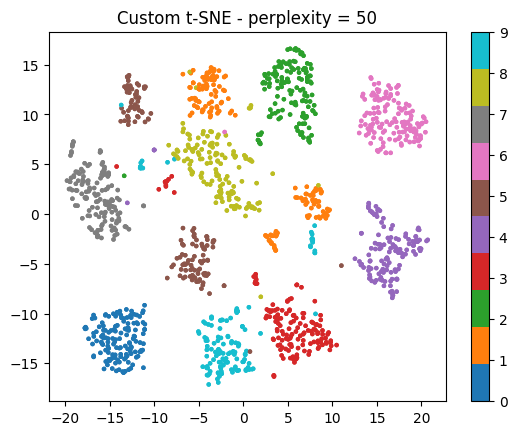

Iteration 100: KL divergence = 2.3105068447596286
Iteration 200: KL divergence = 1.7421237776701217
Iteration 300: KL divergence = 1.5304902041887711
Iteration 400: KL divergence = 1.409061964349728
Iteration 500: KL divergence = 1.3273615552008946
Iteration 600: KL divergence = 1.2672976724117608
Iteration 700: KL divergence = 1.2205707332782871
Iteration 800: KL divergence = 1.1826232080518488
Iteration 900: KL divergence = 1.1508770495549674
Iteration 1000: KL divergence = 1.12398593659551


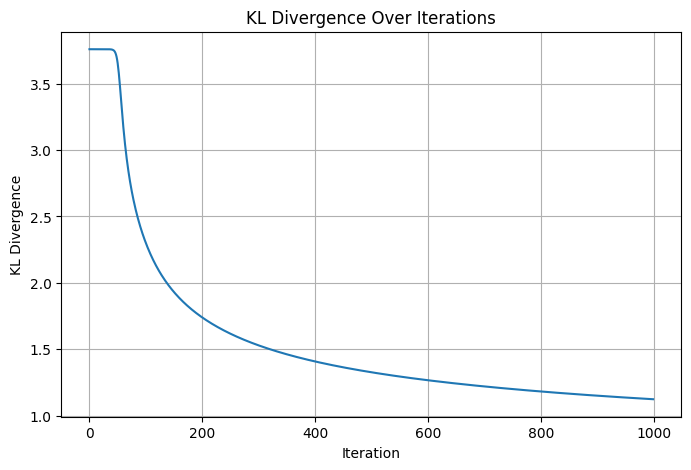

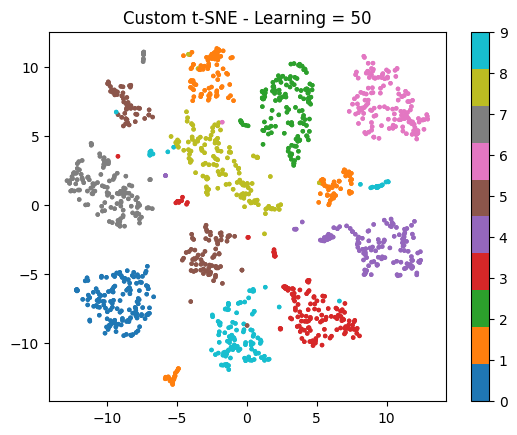

Iteration 100: KL divergence = 1.4427954917254744
Iteration 200: KL divergence = 1.1988550164949956
Iteration 300: KL divergence = 1.0946798815727945
Iteration 400: KL divergence = 1.032743452964077
Iteration 500: KL divergence = 0.9902626161658089
Iteration 600: KL divergence = 0.9587505942106908
Iteration 700: KL divergence = 0.9342190016034557
Iteration 800: KL divergence = 0.9143678747934103
Iteration 900: KL divergence = 0.8979170575757587
Iteration 1000: KL divergence = 0.8839446597557908


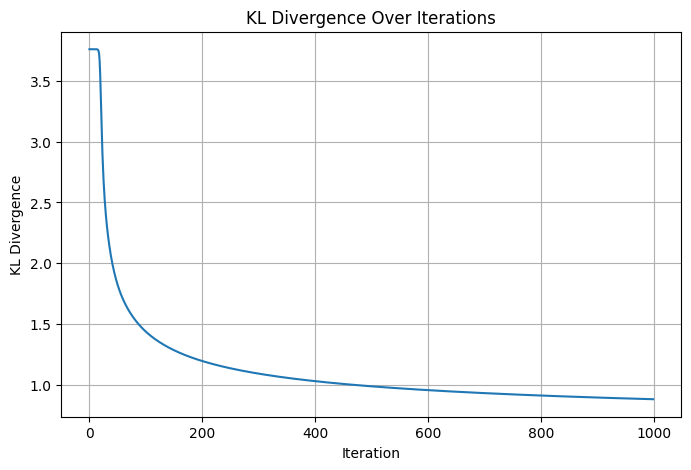

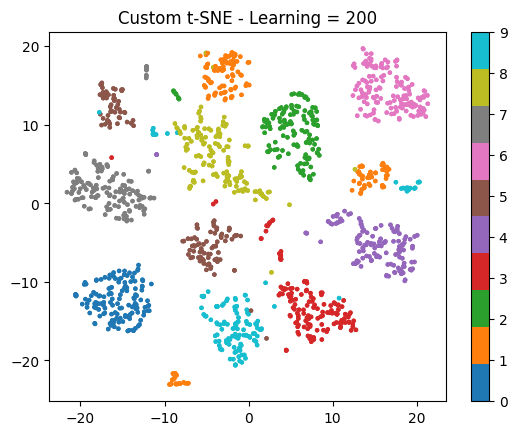

Iteration 100: KL divergence = 1.1589133024017153
Iteration 200: KL divergence = 1.003523825255665
Iteration 300: KL divergence = 0.9359633919869298
Iteration 400: KL divergence = 0.8955812413381085
Iteration 500: KL divergence = 0.8680665553188408
Iteration 600: KL divergence = 0.8477874167399776
Iteration 700: KL divergence = 0.8321542392569697
Iteration 800: KL divergence = 0.8195776892074386
Iteration 900: KL divergence = 0.8091813579294058
Iteration 1000: KL divergence = 0.80039335858531


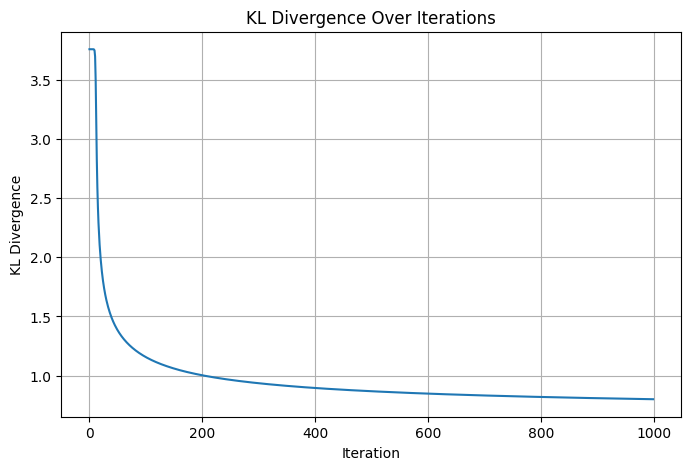

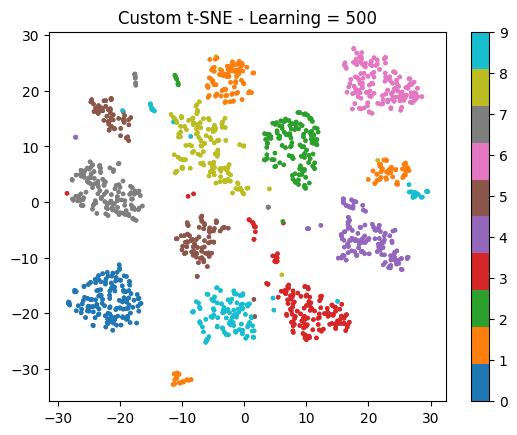

In [ ]:
perplexities = [5, 30, 50]

# Compare perplexities for custom t-SNE
for perplexity in perplexities:
    start_custom = time.time()
    custom_tsne = CustomTSNE(n_components=2, perplexity=perplexity)
    custom_Y = custom_tsne.fit_transform(X_train)
    end_custom = time.time()

    plt.figure()
    plt.scatter(custom_Y[:, 0], custom_Y[:, 1], s=5, c=y_train.astype(int), cmap='tab10')
    plt.scatter(custom_Y[:, 0], custom_Y[:, 1], s=5, c=y_train.astype(int), cmap='tab10')
    plt.colorbar()
    plt.title('Custom t-SNE - perplexity = ' + str(perplexity))
    plt.show()

learning_rates = [50, 200, 500]

# Compare learning rates for custom t-SNE
for learning_rate in learning_rates:
    start_custom = time.time()
    custom_tsne = CustomTSNE(n_components=2, perplexity=30, learning_rate=learning_rate)
    custom_Y = custom_tsne.fit_transform(X_train)
    end_custom = time.time()

    plt.figure()
    plt.scatter(custom_Y[:, 0], custom_Y[:, 1], s=5, c=y_train.astype(int), cmap='tab10')
    plt.scatter(custom_Y[:, 0], custom_Y[:, 1], s=5, c=y_train.astype(int), cmap='tab10')
    plt.colorbar()
    plt.title('Custom t-SNE - Learning = ' + str(learning_rate))
    plt.show()


Perplexity:
At perplexity = 5, the embeddings focus too much on local neighborhoods, resulting in scattered and less cohesive clusters, making it unsuitable for capturing the overall structure. Both perplexity = 30 and perplexity = 50 produced similar results, with well-separated and compact clusters that balance local and global structures effectively. However, perplexity = 50 is the better choice as it later yielded a higher silhouette score, indicating superior cluster separation and overall embedding quality for this dataset. This makes perplexity = 50 the optimal setting for this task.


LR: At learning rate = 50, the convergence is slower, resulting in less compact clusters and weaker global structure. At learning rate = 200, the clusters are well-separated, compact, and balanced, achieving a good trade-off between local and global structure. At learning rate = 500, the clusters remain distinct and well-separated, but the embedding shows slightly more emphasis on global structure, which can stretch the distances between clusters. Overall, learning rate = 200 provides the most balanced and refined embedding for this dataset.






## Compare implementations

Iteration 100: KL divergence = 1.16475903695301
Iteration 200: KL divergence = 0.9699267872596408
Iteration 300: KL divergence = 0.8894180290202659
Iteration 400: KL divergence = 0.8425583912176735
Iteration 500: KL divergence = 0.8109939495239155
Iteration 600: KL divergence = 0.78790051212008
Iteration 700: KL divergence = 0.7699951080964117
Iteration 800: KL divergence = 0.755557303590279
Iteration 900: KL divergence = 0.7438206796815415
Iteration 1000: KL divergence = 0.7340244464240296


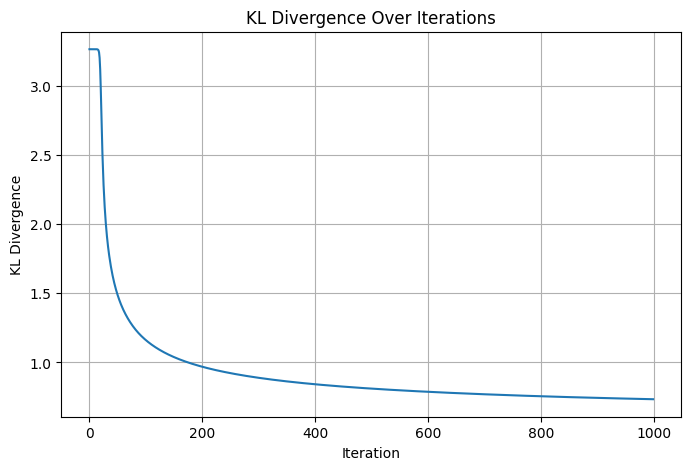

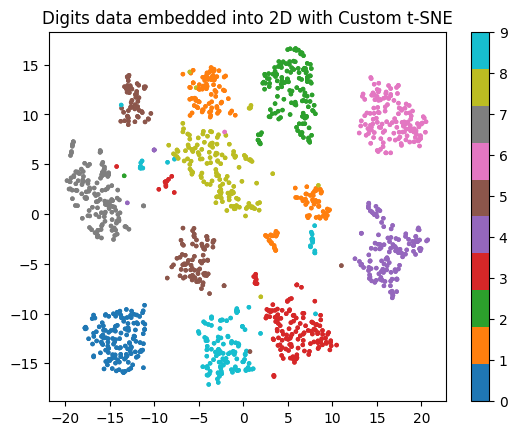

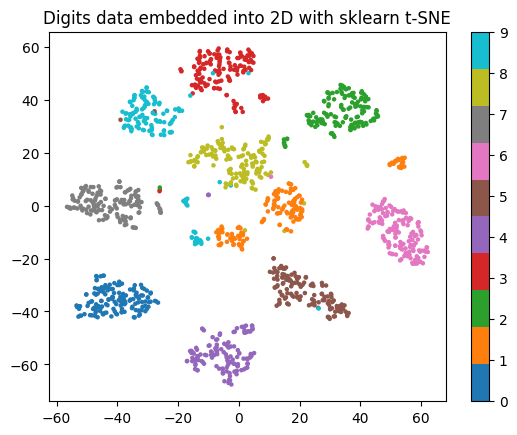

In [18]:
# Run your custom t-SNE implementation
start_custom = time.time()
custom_tsne = CustomTSNE(n_components=2, perplexity=50, learning_rate=200)
custom_Y = custom_tsne.fit_transform(X_train)
end_custom = time.time()

# Run sklearn t-SNE
start_sklearn = time.time()
sk_tsne = TSNE(n_components=2, init='random', perplexity=15)
sk_Y = sk_tsne.fit_transform(X_train)
end_sklearn = time.time()

# Visualization of the result
plt.figure()
plt.scatter(custom_Y[:, 0], custom_Y[:, 1], s=5, c=y_train.astype(int), cmap='tab10')
plt.scatter(custom_Y[:, 0], custom_Y[:, 1], s=5, c=y_train.astype(int), cmap='tab10')
plt.colorbar()
plt.title('Digits data embedded into 2D with Custom t-SNE')

plt.figure()
plt.scatter(sk_Y[:, 0], sk_Y[:, 1], s=5, c=y_train.astype(int), cmap='tab10')
plt.colorbar()
plt.title('Digits data embedded into 2D with sklearn t-SNE')
plt.show()

In [8]:
print(f"Custom t-SNE computation time: {end_custom - start_custom:.2f} seconds")
print(f"sklearn t-SNE computation time: {end_sklearn - start_sklearn:.2f} seconds")


Custom t-SNE computation time: 215.56 seconds
sklearn t-SNE computation time: 9.29 seconds


The custom t-SNE embedding produces compact clusters with well-preserved local structures but less variation in inter-cluster spacing, focusing more on local relationships. In contrast, sklearn’s t-SNE shows better separation between clusters, preserving global structure more effectively, though some clusters appear slightly more dispersed.

The custom implementation manually computes high-dimensional probabilities, applies explicit gradient descent with momentum, and is modular for learning and exploration. Sklearn’s t-SNE, however, uses advanced approximations like Barnes-Hut and FFT for faster computation and supports features like PCA initialization and early exaggeration, making it more efficient and scalable. While the custom t-SNE emphasizes transparency and local detail, sklearn’s version is better suited for larger datasets and general-purpose use. (Explains the diff in running time)





Silhouette Score: Quantifies the quality of cluster separation. A higher score indicates better-defined clusters.








In [9]:
custom_silhouette = silhouette_score(custom_Y, y_train)
sklearn_silhouette = silhouette_score(sk_Y, y_train)

print(f"Silhouette Score - Custom t-SNE: {custom_silhouette:.4f}")
print(f"Silhouette Score - sklearn t-SNE: {sklearn_silhouette:.4f}")


Silhouette Score - Custom t-SNE: 0.4181
Silhouette Score - sklearn t-SNE: 0.5289


The Silhouette Score quantifies how well-separated the clusters are, with higher values indicating better-defined clusters. The custom t-SNE implementation achieves a score of 0.4181, reflecting good local structure preservation but less distinction between clusters in the global context. In contrast, sklearn’s t-SNE achieves a significantly higher score of 0.5289, indicating better-defined and more distinct clusters overall.

Distance Distribution: Histograms compare pairwise distances between points, highlighting how the algorithms distribute embeddings in space.


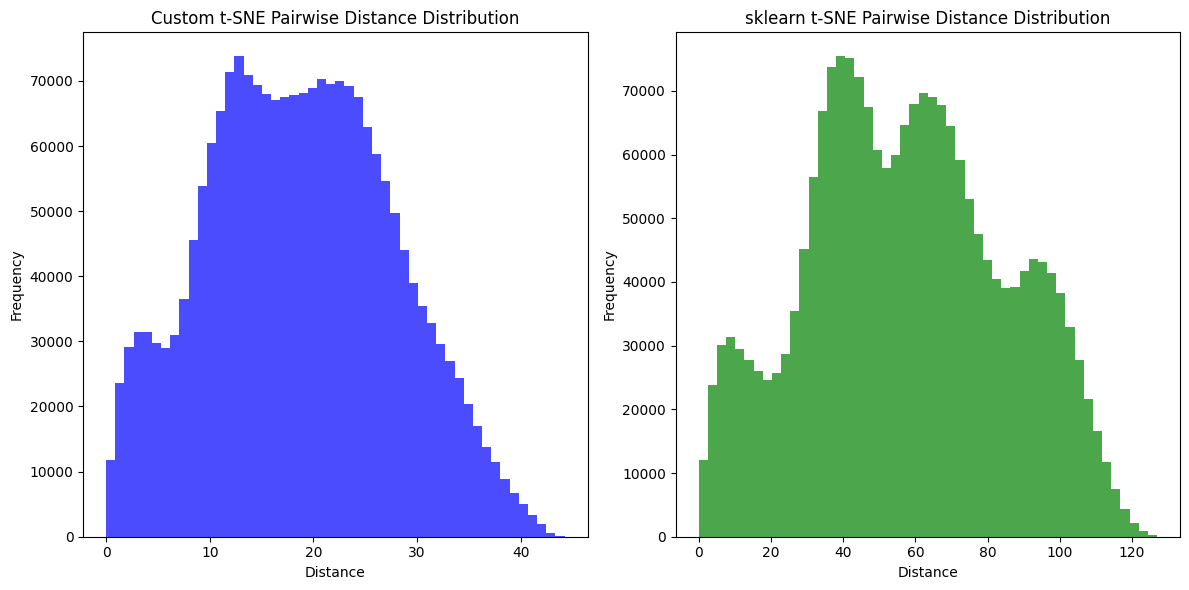

In [20]:
# Plot distributions of distances for embeddings
custom_distances = np.sqrt(np.sum((custom_Y[:, None, :] - custom_Y[None, :, :])**2, axis=2))
sklearn_distances = np.sqrt(np.sum((sk_Y[:, None, :] - sk_Y[None, :, :])**2, axis=2))

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.hist(custom_distances.flatten(), bins=50, color='blue', alpha=0.7)
plt.title('Custom t-SNE Pairwise Distance Distribution')
plt.xlabel('Distance')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
plt.hist(sklearn_distances.flatten(), bins=50, color='green', alpha=0.7)
plt.title('sklearn t-SNE Pairwise Distance Distribution')
plt.xlabel('Distance')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()


The pairwise distance distributions show that the custom t-SNE (left) has a narrower range, resulting in tighter, more compact clusters but weaker global separation. Sklearn t-SNE (right) has a broader range, allowing better representation of global structure and more distinct cluster separation, aligning with its higher Silhouette Score. This difference stems from sklearn’s advanced techniques, such as early exaggeration, which emphasize global separation.


# t-SNE extension - mapping new samples
Demonstrate your t-SNE transformation procedure.

Add plots and figures.

Please use the cell below to describe your suggested approach in detail. Use formal notations where appropriate.
Describe and discuss your results.

Text(0.5, 1.0, 'Digits data embedded into 2D with Custom t-SNE')

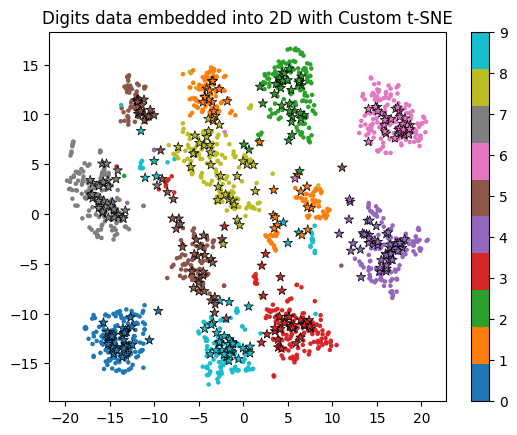

In [21]:
# Transform new data
custom_Y_new = custom_tsne.transform(X_train,custom_Y,X_test)

# Visualization of the result
plt.figure()
plt.scatter(custom_Y[:, 0], custom_Y[:, 1], s=5, c=y_train.astype(int), cmap='tab10')
plt.scatter(custom_Y_new[:, 0], custom_Y_new[:, 1], marker = '*', s=50, linewidths=0.5, edgecolors='k', c=y_test.astype(int), cmap='tab10')
plt.colorbar()
plt.title('Digits data embedded into 2D with Custom t-SNE')

This plot shows a 2D t-SNE embedding of digit data, with dots representing the training set and stars representing the test set. Each color corresponds to a digit label (0–9), and the stars align well with the clusters of dots, indicating consistent mapping of test data into the existing embedding. This result demonstrates the ability of the t-SNE algorithm to preserve relationships between data points while effectively embedding new data into an existing visualization.

In order to evaluate the transform method we will use again the Silhouette Score.

In [17]:
from sklearn.metrics import silhouette_score

# Compute silhouette score for the low-dimensional embedding
sil_score = silhouette_score(custom_Y, y_train)
print(f"Silhouette Score for Training Data: {sil_score:.2f}")

# Optionally, compute it for the transformed test data
sil_score_test = silhouette_score(custom_Y_new, y_test)
print(f"Silhouette Score for Test Data: {sil_score_test:.2f}")

Silhouette Score for Training Data: 0.42
Silhouette Score for Test Data: 0.45


The silhouette scores of 0.42 for the training data and 0.45 for the newly transformed test data indicate that the test points align well with the clustering structure learned from the training data. This suggests that the t-SNE embedding effectively preserved the relationships between the test points and their closest clusters in the low-dimensional space. The slightly higher score for the test data reflects good consistency, indicating that the transformed points integrate smoothly into the existing embedding.

# Use of generative AI
Please use the cell below to describe your use of generative AI in this assignment.

We used ChatGPT to get an initial proposal for the algorithm and to check if we understood the overall structure and implementation. Afterward, we watched videos online and read additional materials to ensure we fully understood the algorithm. When computational issues arose due to heavy calculations, we resolved them ourselves based on our understanding of the function and the process.

We also used ChatGPT to refine and articulate our written answers to the questions. We provided the ideas, and it helped us phrase them more clearly and professionally.

Additionally, we utilized ChatGPT to simplify syntax, especially when generating graphs or visualizations, making the code more concise and readable.